# 11 - HGAOEnKF+ extensions

`hgaoenkf_plus` is the hybrid gain analog offline EnKF of notebook 10 with three terms the
published method does not carry. It runs through the same three lanes, so notebook 09
compares it row for row against the baseline and against the published extension's earlier
results, which are on disk under `hgaoenkf_plus_old`.

**One estimator, not several.** All three terms are ordinary tunable parameters alongside
`k` and `hybrid_w`, each swept from zero, and zero on all three is the baseline's own
estimator. Each lane picks its own point on that grid, so the ablation is a set of rows in
one run rather than a ladder of separate ones, and a lane that finds a term worthless
reports the published method rather than a worse one.

**The selection score** ranks candidates by the marginal likelihood
`(y - Hx)' (c H B H' + R)^-1 (y - Hx)` instead of the R-weighted residual. A candidate is
not the truth but the centre of a background with covariance `B`, and the update that
consumes the ensemble already carries that spread. At `c = 0` the two rules coincide
exactly. `c` is held at the value that makes selection assume the same background the
update applies, and swept only in the sensitivity pass at the end.

**The redundancy penalty** turns selection from a ranking into a set. Every published rule
scores each candidate alone, so the best `k` can be near-duplicates: the archive is a
trajectory, and states close in time predict a sparse network almost identically. The
penalty charges a candidate for resembling one already taken, as a cosine in the same
whitened coordinates the score uses. `redundancy_theta = 0` is the ranking itself.

**The tendency modes** augment the analog deviations with the archive's local rate of
change around each selected member, differenced over `tendency_lag_yr`. Selection draws
members that agree with the observations, so they agree with each other there too and the
covariance is flattest in the directions the gain leans on hardest; the tendency modes
never had to agree with anything. They are the only part of the estimator that reads the
archive's time ordering for anything but the exclusion band. `tendency_theta = 0` leaves
both the mean and the covariance untouched, to the bit.

Held fixed rather than tuned, each for a stated reason:

- **The taper** is inherited per lane from the 3DVar runs in notebook 07, exactly as the
  baseline inherits it, so the comparison stays one of estimators.
- **The treatment of observation staleness**, settled on the 3DVar lanes.
- **The evidence scale `c`**, held and swept only as a sensitivity pass.
- **The analog pool** is the prior half on the two same-model lanes, disjoint from every
  truth by construction.

Tuned on each lane's own selection split: `k`, `hybrid_w`, `tendency_theta`,
`tendency_lag_yr`, `redundancy_theta`, `b_scale`, and the analog covariance's own
localization lengthscale. The trajectory lane inherits its operating point from the PPE
grid, as the baseline's does.

In [1]:
%load_ext autoreload
%autoreload 2

# Cap BLAS threading before numpy loads, for the same reason notebook 07 does: the
# assimilation runs thousands of small eigendecompositions, a size where splitting each
# one across cores costs more than it saves. HGAOEnKF runs two per analysis rather than
# one, so the cap matters more here, not less.
import os

for _var in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS",
             "NUMEXPR_NUM_THREADS", "VECLIB_MAXIMUM_THREADS"):
    os.environ[_var] = "1"

import json
import shutil
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath(".."))

from paleoreco.data import build_prior_cube
from paleoreco.assim.analog import ANALOG_EVIDENCE, EVIDENCE_SCALE
from paleoreco.assim.hgaoenkf import make_hgaoenkf
from paleoreco.assim.observations import (
    attach_site_stats, collapse_to_samples, load_observations, observation_site_stats,
)
from paleoreco.assim import experiments as ex

plt.rcParams["figure.dpi"] = 110
DATA = "../data"
OUT = Path("../outputs/da")
FIG = Path("../outputs/figures/11_hgaoenkf_plus")
FIG.mkdir(parents=True, exist_ok=True)

# Which stages this pass runs. Each clears only its own artefacts, so switching one off
# leaves the others on disk. Later stages inherit their operating point from the PPE and
# withholding grids, so those need a run in this pass or already written.
RUN_PPE = True
RUN_LOC_SWEEP = True
RUN_TRAJECTORY = True
RUN_WITHHOLDING = True
RUN_LOC_SWEEP_WH = True
RUN_EVIDENCE_SCALE = True

RULE = ANALOG_EVIDENCE
ESTIMATOR = ex.hgaoenkf_estimator(RULE)

# The tuning grid. b_scale is swept inside every config, as it is for 3DVar. The lag says
# nothing where the tendency weight is zero, so the term axes collapse to the distinct
# states rather than their outer product.
K_GRID = ex.K_GRID
W_GRID = ex.HYBRID_W_GRID
TENDENCY_THETA_GRID = ex.TENDENCY_THETA_GRID
TENDENCY_LAG_YR_GRID = ex.TENDENCY_LAG_YR_GRID
REDUNDANCY_THETA_GRID = ex.REDUNDANCY_THETA_GRID
TERM_GRIDS = dict(tendency_theta_grid=TENDENCY_THETA_GRID,
                  tendency_lag_yr_grid=TENDENCY_LAG_YR_GRID,
                  redundancy_theta_grid=REDUNDANCY_THETA_GRID)
TERM_STATES = ex.analog_term_states(TENDENCY_THETA_GRID, TENDENCY_LAG_YR_GRID,
                                    REDUNDANCY_THETA_GRID)
N_CONFIGS = len(K_GRID) * len(W_GRID) * len(TERM_STATES)

# Lengthscales for the analog covariance's own taper, swept at the selected operating point
# rather than joining the grid, which would multiply the withholding pass.
LOC_GRID = ex.ANALOG_LOCALIZATION_GRID_PPE
LOC_GRID_WH = ex.ANALOG_LOCALIZATION_GRID_WH
# Relative margin a swept value has to beat the incumbent by before it is adopted. The
# paired intervals on these lanes run about 0.03 wide on an rRMSE near 0.53, so a few tenths
# of a per cent is not resolvable and a plain argmin over a flat sweep selects noise.
SEL_MARGIN = 0.01
# Background amplitudes the prior-predictive rule is scored against. Zero is the misfit
# rule, so the curve reports the reduction as well as the sensitivity.
EVIDENCE_SCALE_GRID = (0.0, 1.0, 2.0, 5.0, 10.0, 20.0)

# The term settings the ablation reads out of the grid, named for the write-up.
TERM_LABEL = {(0.0, 0.0): "neither", (1.0, 0.0): "tendency only",
              (0.0, 1.0): "redundancy only", (1.0, 1.0): "both"}
TERM_COLS = ["tendency_theta", "tendency_lag_yr", "redundancy_theta"]


def loc_label(km):
    """How a lengthscale reads in a table; None is the static covariance's own."""
    return "static" if km is None else f"{int(km)}"


def pick_lengthscale(sub, grid):
    """The lengthscale a sweep selects, holding the inherited one inside ``SEL_MARGIN``.

    Reads the winner off the label rather than the value. A grid holding ``None`` beside
    floats becomes a float column once it reaches a frame, so ``None`` comes back as NaN,
    and NaN no longer means "inherit the static one" to anything downstream: it reaches
    Gaspari-Cohn, every comparison against it is false, and the taper silences the analog
    covariance instead of localizing it.
    """
    by_label = sub.set_index("lengthscale")["selection rrmse"]
    best, incumbent = by_label.idxmin(), loc_label(None)
    if incumbent in by_label.index and by_label[best] >= by_label[incumbent] * (1 - SEL_MARGIN):
        best = incumbent
    return {loc_label(km): km for km in grid}[best]


def terms_of(cfg):
    """The three extension parameters a lane's config selected, ready to pass on."""
    return {col: float(cfg["selected"][col]) for col in TERM_COLS}


def describe(terms):
    """One line naming which terms a selected config turned on."""
    on = []
    if terms["tendency_theta"] > 0:
        on.append(f"tendency {terms['tendency_theta']:g} @ {terms['tendency_lag_yr']:.0f} yr")
    if terms["redundancy_theta"] > 0:
        on.append(f"redundancy {terms['redundancy_theta']:g}")
    return ", ".join(on) if on else "neither term (the published estimator)"


print(f"k {K_GRID} x hybrid_w {W_GRID} x term states -> {N_CONFIGS} configs per lane")
print(f"tendency theta {TENDENCY_THETA_GRID}, lag {TENDENCY_LAG_YR_GRID} yr, "
      f"redundancy {REDUNDANCY_THETA_GRID}")
print(f"evidence scale held at {EVIDENCE_SCALE}, swept over {EVIDENCE_SCALE_GRID}")

k (20, 40, 60, 100) x hybrid_w (0.0, 0.25, 0.5, 0.75, 1.0) x term states -> 120 configs per lane
tendency theta (0.0, 1.0), lag (200.0, 400.0) yr, redundancy (0.0, 0.25)
evidence scale held at 1.0, swept over (0.0, 1.0, 2.0, 5.0, 10.0, 20.0)


## Prior cube, observations, and the inherited tapers

In [2]:
P = build_prior_cube(prior_csv=f"{DATA}/Prior.csv", cache_path=f"{DATA}/cache/prior_cube.npz")
cube, ages, lats, lons, valid = P["cube"], P["ages"], P["lats"], P["lons"], P["valid"]

long_ppe = load_observations(f"{DATA}/Observation.csv")
long_wh = attach_site_stats(long_ppe, observation_site_stats(collapse_to_samples(long_ppe)))

D3 = OUT / "3dvar_pixel"
TAPER_KEYS = ["localization_km", "shrinkage_lambda", "alpha"]


def inherited_taper(config_name):
    """The taper the 3DVar run of one lane selected."""
    path = D3 / config_name
    if not path.exists():
        raise FileNotFoundError(
            f"{path} is missing. HGAOEnKF inherits its taper from the 3DVar lanes, so run "
            "notebook 07 first, or pass a taper to the grid drivers directly.")
    win = json.load(open(path))["selected"]
    return {k: win[k] for k in TAPER_KEYS}


TAPER_PPE = inherited_taper("ppe_config.json")
TAPER_WH = inherited_taper("withholding_random_config.json")
print(f"cube {cube.shape}, {len(ages)} ages, {long_ppe['site'].nunique()} sites")
print(f"PPE / trajectory taper : {TAPER_PPE}")
print(f"withholding taper      : {TAPER_WH}")

cube (804, 2, 32, 64), 804 ages, 187 sites
PPE / trajectory taper : {'localization_km': 15000.0, 'shrinkage_lambda': 0.0, 'alpha': 0.25}
withholding taper      : {'localization_km': None, 'shrinkage_lambda': 0.5, 'alpha': 0.75}


## Cost check

The grid here is wider than the baseline's by the number of extension-term states, and the
withholding lane dominates the total. Neither new term changes the cost of one analysis
measurably: the tendency rows are a second small matrix product inside a covariance build
two orders of magnitude larger, and the greedy draw is `k` dot products against the pool.
The cost is the grid, not the estimator.

Measure before committing. The baseline notebook's own table sizes one config; multiply by
`N_CONFIGS` rather than by the baseline's config count.

In [3]:
COST_CHECK = False    # one config on each lane, to size the grid before committing to it

if COST_CHECK:
    tmp = OUT / "_cost_check"
    shutil.rmtree(tmp, ignore_errors=True)
    for lane, fn, obs, taper, kw in (
        ("ppe", ex.run_hgaoenkf_ppe_grid, long_ppe, TAPER_PPE,
         dict(n_noise=5, truth_stride=10)),
        ("withholding", ex.run_hgaoenkf_withholding_grid, long_wh, TAPER_WH,
         dict(k_folds=5)),
    ):
        t0 = time.time()
        fn(cube, ages, lats, lons, valid, obs, str(tmp / lane),
           k_grid=(60,), hybrid_w_grid=(0.75,), selection=RULE, **taper, **kw)
        # A one-point grid still runs the winner pass, so halve it for the per-config cost.
        per = (time.time() - t0) / 2
        print(f"{lane}: {per:.0f}s per config -> {N_CONFIGS} configs "
              f"~ {(N_CONFIGS + 1) * per / 60:.0f} min")
    shutil.rmtree(tmp, ignore_errors=True)
else:
    print("cost check off")

cost check off


## PPE lane

The same-model lane, and the one with the statistical power: 41 truths, each scored over
five drawn networks, four for selection and one held out. Every extension term is tuned
here on the selection split alone.

In [4]:
# Files each stage owns. The PPE and withholding lanes share one metrics CSV, as they do
# for 3DVar, so clearing has to be per lane rather than per directory.
HG = OUT / f"{ESTIMATOR}_pixel"
HG_TRAJ = OUT / f"{ESTIMATOR}_pixel_trajectory"
HG_LOC = OUT / f"{ESTIMATOR}_pixel_localization"
HG_LOC_WH = OUT / f"{ESTIMATOR}_localization_wh"
HG_SCALE = OUT / f"{ESTIMATOR}_scale"

LANE_FILES = {
    "ppe": ("ppe_config.json", "ppe_analysis.npz", "ppe_skill_vs_distance.npz"),
    "withholding_random": ("withholding_random_config.json",
                           "withholding_random_predictions.npz"),
}


def clear_lane(directory, lane):
    """Drop one lane's artefacts and its rows from the appended metrics CSV."""
    for name in LANE_FILES[lane]:
        (directory / name).unlink(missing_ok=True)
    csv = directory / "metrics.csv"
    if not csv.exists():
        return
    rest = pd.read_csv(csv)
    rest = rest[rest["lane"] != lane]
    if len(rest):
        rest.to_csv(csv, index=False)
    else:
        csv.unlink()


def last_run(path, lane_flag, lane_name):
    """The config a lane wrote, or None if that lane has never run here."""
    if path.exists():
        return json.load(open(path))
    if lane_flag:
        raise FileNotFoundError(f"{path} was expected after running the {lane_name} lane")
    print(f"[{ESTIMATOR}] no previous {lane_name} run at {path}; produce one with "
          f"RUN_{lane_name.upper()} = True")
    return None


HG.mkdir(parents=True, exist_ok=True)
if RUN_PPE:
    clear_lane(HG, "ppe")
    print(f"[{ESTIMATOR}] ppe analog grid, {N_CONFIGS} configs")
    ex.run_hgaoenkf_ppe_grid(cube, ages, lats, lons, valid, long_ppe, str(HG),
                             k_grid=K_GRID, hybrid_w_grid=W_GRID, **TERM_GRIDS,
                             selection=RULE, n_noise=5, truth_stride=10,
                             progress_every=10, **TAPER_PPE)
else:
    print(f"[{ESTIMATOR}] ppe grid off; reading the last run")

PPE_CFG = last_run(HG / "ppe_config.json", RUN_PPE, "ppe")
if PPE_CFG is not None:
    K_SEL, W_SEL = PPE_CFG["selected"]["analog_k"], PPE_CFG["selected"]["hybrid_w"]
    TERMS_SEL = terms_of(PPE_CFG)
    print(f"selected on PPE: k={K_SEL}, hybrid_w={W_SEL}, "
          f"b_scale={PPE_CFG['selected']['b_scale']}")
    print(f"  terms: {describe(TERMS_SEL)}")

[hgaoenkf_plus] ppe analog grid, 120 configs
  analog-grid config 1/120 (1%, elapsed 29s, eta 3469s)
  analog-grid config 2/120 (2%, elapsed 57s, eta 3341s)
  analog-grid config 3/120 (2%, elapsed 90s, eta 3526s)
  analog-grid config 4/120 (3%, elapsed 126s, eta 3662s)
  analog-grid config 5/120 (4%, elapsed 161s, eta 3711s)
  analog-grid config 6/120 (5%, elapsed 197s, eta 3736s)
  analog-grid config 7/120 (6%, elapsed 224s, eta 3613s)
  analog-grid config 8/120 (7%, elapsed 252s, eta 3528s)
  analog-grid config 9/120 (8%, elapsed 287s, eta 3542s)
  analog-grid config 10/120 (8%, elapsed 322s, eta 3538s)
  analog-grid config 11/120 (9%, elapsed 357s, eta 3541s)
  analog-grid config 12/120 (10%, elapsed 393s, eta 3533s)
  analog-grid config 13/120 (11%, elapsed 421s, eta 3463s)
  analog-grid config 14/120 (12%, elapsed 451s, eta 3415s)
  analog-grid config 15/120 (12%, elapsed 486s, eta 3404s)
  analog-grid config 16/120 (13%, elapsed 524s, eta 3409s)
  analog-grid config 17/120 (14%, 

### Do the extension terms earn their place?

The ablation is a read of the grid rather than a separate run: the `(0, 0)` state is the
published estimator, so the four corners sit in the same metrics CSV at the same tuned `k`,
`hybrid_w` and `b_scale`.

Read the `neither` row first. If the grid's winner is that row, the terms bought nothing on
this lane and the estimator has reverted to the published one, which is a result and not a
failure. If a term wins, check it wins by more than the lane resolves before claiming it:
the paired intervals here run near 0.03 on an rRMSE near 0.53, so a margin of a few tenths
of a per cent is noise. Notebook 09 carries the paired test.

In [5]:
def ablation_table(directory, lane, label):
    """Best selection-split rRMSE for each corner of the two term axes."""
    path = directory / "metrics.csv"
    if not path.exists():
        return None
    m = pd.read_csv(path)
    sel = m[(m.lane == lane) & (m.split == "selection") & (m.method == label)
            & (m.channel == "pooled") & (m.do_event == "all") & (m.metric == "rrmse")]
    if sel.empty:
        return None
    rows = []
    for (tendency, redundancy), group in sel.groupby(
            [sel.tendency_theta > 0, sel.redundancy_theta > 0]):
        best = group.loc[group["value"].idxmin()]
        rows.append({"terms": TERM_LABEL[(float(tendency), float(redundancy))],
                     "selection rrmse": float(best["value"]),
                     "k": int(best["analog_k"]), "hybrid_w": float(best["hybrid_w"]),
                     "lag_yr": float(best["tendency_lag_yr"]),
                     "b_scale": float(best["b_scale"])})
    tab = pd.DataFrame(rows).set_index("terms")
    baseline = tab.loc["neither", "selection rrmse"]
    tab["gain vs neither"] = 100 * (baseline - tab["selection rrmse"]) / baseline
    return tab.reindex([v for v in TERM_LABEL.values() if v in tab.index])


PPE_ABL = ablation_table(HG, "ppe", ex.method_label(ESTIMATOR))
if PPE_ABL is None:
    print("no PPE rows yet")
else:
    print("PPE selection split, best over (k, hybrid_w, b_scale) within each term state;\n"
          "'neither' is the published estimator exactly:")
    display(PPE_ABL.round({"selection rrmse": 4, "hybrid_w": 2, "lag_yr": 0,
                           "b_scale": 2, "gain vs neither": 2}))

PPE selection split, best over (k, hybrid_w, b_scale) within each term state;
'neither' is the published estimator exactly:


,selection rrmse,k,hybrid_w,lag_yr,b_scale,gain vs neither
terms,,,,,,
neither,0.5240,60,0.75,0.0,5.0,0.00
tendency only,0.5095,40,1.00,400.0,5.0,2.76
redundancy only,0.5181,100,1.00,0.0,5.0,1.11
both,0.5071,100,1.00,400.0,2.0,3.22


### The analog covariance's own localization lengthscale

Sun et al. (2024) Table 2 give the flow-dependent covariance a lengthscale separate from
the static one, tighter as the ensemble shrinks. Their values are radians on another model,
grid and network, so the schedule transfers but the number does not. Swept at the selected
operating point rather than joining the grid.

In [6]:
LOC_SEL = None

if RUN_LOC_SWEEP:
    if PPE_CFG is None:
        raise RuntimeError("the lengthscale sweep runs at the PPE-selected operating "
                           "point; run the PPE grid first")
    shutil.rmtree(HG_LOC, ignore_errors=True)
    t0 = time.time()
    for km in LOC_GRID:
        ex.run_ppe(cube, ages, lats, lons, valid, long_ppe, str(HG_LOC),
                   make_method=make_hgaoenkf(
                       cube, ages, lats, lons, k=K_SEL, hybrid_w=W_SEL,
                       selection=RULE, analog_localization_km=km, **TERMS_SEL),
                   estimator=ex.analog_localization_estimator(RULE, km),
                   method_cols=ex.analog_cols(K_SEL, W_SEL, **TERMS_SEL),
                   n_noise=5, truth_stride=10, **TAPER_PPE)
        print(f"  loc={loc_label(km)} done (elapsed {time.time() - t0:.0f}s)", flush=True)
else:
    print(f"[{ESTIMATOR}] analog lengthscale sweep off; reading the last run")

if not (HG_LOC / "metrics.csv").exists():
    print(f"[{ESTIMATOR}] no lengthscale sweep on disk; staying at the static value")
else:
    M_LOC = pd.read_csv(HG_LOC / "metrics.csv")
    rows = []
    for km in LOC_GRID:
        label = ex.method_label(ex.analog_localization_estimator(RULE, km))
        sel = M_LOC[(M_LOC.split == "selection") & (M_LOC.method == label)
                    & (M_LOC.channel == "pooled") & (M_LOC.do_event == "all")
                    & (M_LOC.metric == "rrmse")]
        if len(sel):
            rows.append({"km": km, "lengthscale": loc_label(km),
                         "selection rrmse": float(sel["value"].min())})
    loc_tab = pd.DataFrame(rows)
    print("PPE selection split against the analog lengthscale, at the selected point:")
    display(loc_tab.set_index("lengthscale")[["selection rrmse"]].round(4))
    LOC_SEL = pick_lengthscale(loc_tab, LOC_GRID)
    print(f"selected analog lengthscale (adoption margin {100 * SEL_MARGIN:.0f}%): "
          f"{loc_label(LOC_SEL)}")

  loc=static done (elapsed 117s)
  loc=5000 done (elapsed 228s)
  loc=7500 done (elapsed 338s)
  loc=10000 done (elapsed 445s)


/Users/evgenigeorgiev/Documents/Imperial/diss/sparse_paleoclimate_field_reconstruction/paleoreco/assim/ensrf.py:74: RuntimeWarning: invalid value encountered in sqrt
  return b_scale * (wb.G @ (q / (w + np.sqrt(w))[:, None]))


  loc=20000 done (elapsed 554s)
PPE selection split against the analog lengthscale, at the selected point:


,selection rrmse
lengthscale,
static,0.5071
5000,0.5916
7500,0.5296
10000,0.5120
20000,0.5109


selected analog lengthscale (adoption margin 1%): static


In [7]:
# The grid above ran at the static lengthscale, so where the sweep moved it the operating
# point was selected under a covariance the estimator no longer uses. Re-grid there; where
# the sweep kept the static value the rows on disk already sit at the selected point.
if LOC_SEL is not None and RUN_PPE and RUN_LOC_SWEEP:
    clear_lane(HG, "ppe")
    print(f"[{ESTIMATOR}] re-running the ppe grid at analog lengthscale "
          f"{loc_label(LOC_SEL)}")
    ex.run_hgaoenkf_ppe_grid(
        cube, ages, lats, lons, valid, long_ppe, str(HG),
        k_grid=K_GRID, hybrid_w_grid=W_GRID, **TERM_GRIDS, selection=RULE,
        analog_localization_km=LOC_SEL, n_noise=5, truth_stride=10,
        progress_every=10, **TAPER_PPE)
    PPE_CFG = json.load(open(HG / "ppe_config.json"))
    K_SEL, W_SEL = PPE_CFG["selected"]["analog_k"], PPE_CFG["selected"]["hybrid_w"]
    TERMS_SEL = terms_of(PPE_CFG)
    print(f"  re-selected: k={K_SEL}, hybrid_w={W_SEL}, "
          f"b_scale={PPE_CFG['selected']['b_scale']}; terms: {describe(TERMS_SEL)}")
elif LOC_SEL is not None:
    print("the sweep moved the lengthscale, but the grid is off; the rows on disk sit at "
          "whatever lengthscale they were run with")
else:
    print("the sweep kept the static lengthscale; nothing to re-grid")

the sweep kept the static lengthscale; nothing to re-grid


### The selection surface

Error and amplitude at the same operating point, so a flat reconstruction cannot hide
behind an rRMSE that barely moves. Each term state gets its own pair of panels, which is
what shows whether a term shifts the whole surface or only its optimum.

published (neither term): selection-split RRMSE at each (k, hybrid_w), minimised over b_scale:


hybrid_w,0.00,0.25,0.50,0.75,1.00
analog_k,,,,,
20.0,0.5439,0.5361,0.5282,0.5290,0.5389
40.0,0.5436,0.5348,0.5260,0.5242,0.5306
60.0,0.5440,0.5347,0.5269,0.5240,0.5281
100.0,0.5455,0.5358,0.5288,0.5243,0.5253


with the selected terms: selection-split RRMSE at each (k, hybrid_w), minimised over b_scale:


hybrid_w,0.00,0.25,0.50,0.75,1.00
analog_k,,,,,
20.0,0.5481,0.5349,0.5239,0.5153,0.5092
40.0,0.5470,0.5345,0.5239,0.5154,0.5092
60.0,0.5468,0.5341,0.5233,0.5146,0.5081
100.0,0.5476,0.5345,0.5233,0.5142,0.5071


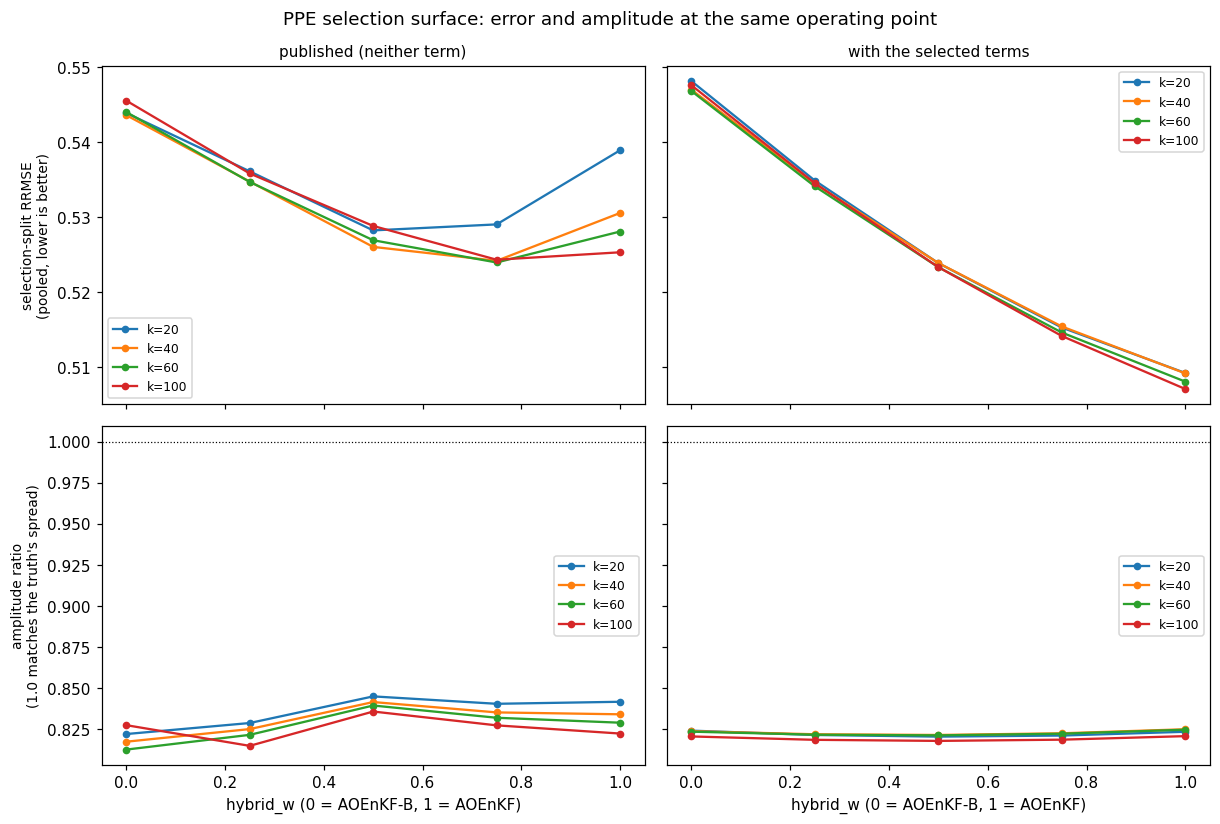

In [8]:
def ppe_surface(directory, label, metric, mask):
    """Selection-split ``metric`` at each (k, hybrid_w), read at the rRMSE-optimal b_scale."""
    m = pd.read_csv(directory / "metrics.csv")
    sel = m[(m.lane == "ppe") & (m.split == "selection") & (m.method == label)
            & (m.channel == "pooled") & (m.do_event == "all")]
    sel = sel[mask(sel)]
    rrmse = sel[sel.metric == "rrmse"]
    keys = ["analog_k", "hybrid_w", "b_scale"]
    best = rrmse.loc[rrmse.groupby(["analog_k", "hybrid_w"])["value"].idxmin(), keys]
    at_best = sel[sel.metric == metric].merge(best, on=keys)
    return at_best.groupby(["analog_k", "hybrid_w"])["value"].min().unstack()


STATES = [("published (neither term)",
           lambda d: (d.tendency_theta == 0) & (d.redundancy_theta == 0)),
          ("with the selected terms",
           lambda d: (d.tendency_theta == TERMS_SEL["tendency_theta"])
           & (d.tendency_lag_yr == TERMS_SEL["tendency_lag_yr"])
           & (d.redundancy_theta == TERMS_SEL["redundancy_theta"]))]
PANELS = (("rrmse", "selection-split RRMSE\n(pooled, lower is better)"),
          ("amplitude", "amplitude ratio\n(1.0 matches the truth's spread)"))

label = ex.method_label(ESTIMATOR)
fig, axes = plt.subplots(len(PANELS), len(STATES), squeeze=False, sharex=True, sharey="row",
                         figsize=(5.6 * len(STATES), 3.8 * len(PANELS)))
for row, (metric, ylabel) in enumerate(PANELS):
    for col, (title, mask) in enumerate(STATES):
        ax = axes[row, col]
        surface = ppe_surface(HG, label, metric, mask)
        if metric == "rrmse":
            print(f"{title}: selection-split RRMSE at each (k, hybrid_w), "
                  "minimised over b_scale:")
            display(surface.round(4))
        for k, values in surface.iterrows():
            ax.plot(values.index, values.values, marker="o", ms=4, label=f"k={int(k)}")
        if metric == "amplitude":
            ax.axhline(1.0, color="k", lw=0.8, ls=":")
            ax.set_xlabel("hybrid_w (0 = AOEnKF-B, 1 = AOEnKF)")
        else:
            ax.set_title(title, fontsize=10)
        if col == 0:
            ax.set_ylabel(ylabel, fontsize=9)
        ax.legend(fontsize=8)
fig.suptitle("PPE selection surface: error and amplitude at the same operating point")
fig.tight_layout()
fig.savefig(FIG / "ppe_selection_surface.png", bbox_inches="tight")
plt.show()

## Trajectory lane

A consecutive run of states scored by timescale, at the PPE-selected operating point. It
grids nothing of its own beyond `b_scale`, which is what keeps it a lane nothing was tuned
on.

In [9]:
if RUN_TRAJECTORY and PPE_CFG is None:
    raise RuntimeError("the trajectory lane runs at the PPE-selected operating point; "
                       "run the PPE grid first")

if RUN_TRAJECTORY:
    shutil.rmtree(HG_TRAJ, ignore_errors=True)
    print(f"[{ESTIMATOR}] trajectory at k={K_SEL}, hybrid_w={W_SEL}, "
          f"analog lengthscale {loc_label(LOC_SEL)}; terms: {describe(TERMS_SEL)}")
    ex.run_trajectory(
        cube, ages, lats, lons, valid, long_ppe, str(HG_TRAJ),
        make_method=make_hgaoenkf(cube, ages, lats, lons, k=K_SEL, hybrid_w=W_SEL,
                                  selection=RULE, analog_localization_km=LOC_SEL,
                                  **TERMS_SEL),
        estimator=ESTIMATOR,
        method_cols=ex.analog_cols(K_SEL, W_SEL, **TERMS_SEL),
        temporal_modes=ex.TEMPORAL_MODES, progress_every=50, **TAPER_PPE)
else:
    print(f"[{ESTIMATOR}] trajectory lane off; reading the last run")

TRAJ_CFG = last_run(HG_TRAJ / "trajectory_config.json", RUN_TRAJECTORY, "trajectory")
if TRAJ_CFG is not None:
    print(f"  scored {TRAJ_CFG['n_covered_ages']} ages, "
          f"skipped {TRAJ_CFG['n_skipped_ages']}")
    print(f"  selection {TRAJ_CFG['selection_ages']} yr BP, "
          f"test {TRAJ_CFG['test_ages']} yr BP")
    print("  b_scale* per method:", TRAJ_CFG["selected_b_scale_by_method"])

[hgaoenkf_plus] trajectory at k=100, hybrid_w=1.0, analog lengthscale static; terms: tendency 1 @ 400 yr, redundancy 0.25
  trajectory age 87/402 (22%, elapsed 22s, eta 80s)
  trajectory age 137/402 (34%, elapsed 47s, eta 91s)
  trajectory age 187/402 (47%, elapsed 68s, eta 78s)
  trajectory age 237/402 (59%, elapsed 87s, eta 61s)
  trajectory age 287/402 (71%, elapsed 108s, eta 43s)
  trajectory age 337/402 (84%, elapsed 128s, eta 25s)
  trajectory age 387/402 (96%, elapsed 148s, eta 6s)
  scored 365 ages, skipped 37
  selection [30025, 34550] yr BP, test [34575, 39125] yr BP
  b_scale* per method: {'hgaoenkf_plus': 0.3, 'hgaoenkf_plus_temporal_add': 0.3, 'hgaoenkf_plus_temporal_deflate': 0.3}


analog-set overlap between neighbouring analyses (25 yr apart):
  mean 0.553, median 0.550, 10th pct 0.470
  fraction of adjacent pairs sharing under half their members: 0.173
  overlap beyond 1000 yr: 0.426 (chance = 0.249)


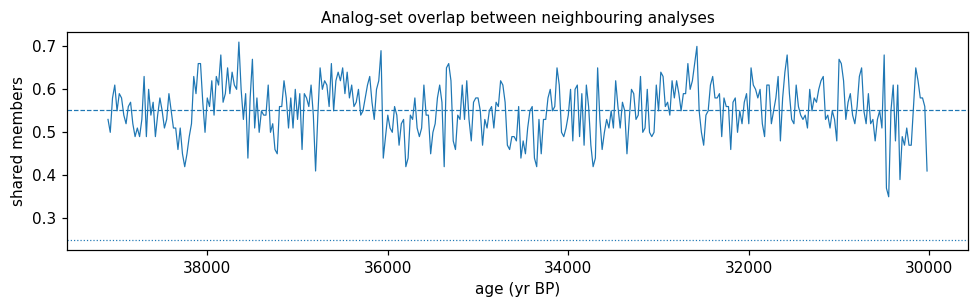


The lane records the selection made by the first treatment in the ladder, which is the uncorrected one; deflating y and R moves which states are chosen, so read this as the structure of analog selection rather than as the deflated run's own set. The redundancy penalty changes what turnover means here: a penalised draw spreads the set deliberately, so lower overlap is expected and is not by itself evidence of instability. Read it next to the band table in notebook 09.


In [10]:
if TRAJ_CFG is None:
    raise RuntimeError("no trajectory run to read")

zt = np.load(HG_TRAJ / "trajectory_analysis.npz")
idx = zt["analog_index"]
step_yr = float(zt["step_yr"])
sets = [set(row.tolist()) for row in idx]
k = idx.shape[1]
chance = k / TRAJ_CFG["prior_meta"]["n_prior_ages"]

adjacent = np.array([len(sets[i] & sets[i + 1]) / k for i in range(len(sets) - 1)])
far = np.array([len(sets[i] & sets[j]) / k
                for i in range(0, len(sets), 17) for j in range(0, len(sets), 19)
                if abs(i - j) * step_yr > 1000])

print(f"analog-set overlap between neighbouring analyses ({step_yr:.0f} yr apart):")
print(f"  mean {adjacent.mean():.3f}, median {np.median(adjacent):.3f}, "
      f"10th pct {np.percentile(adjacent, 10):.3f}")
print(f"  fraction of adjacent pairs sharing under half their members: "
      f"{np.mean(adjacent < 0.5):.3f}")
print(f"  overlap beyond 1000 yr: {far.mean():.3f} (chance = {chance:.3f})")

fig, ax = plt.subplots(figsize=(9, 2.9))
ax.plot(zt["ages"][:-1], adjacent, lw=0.8, color="C0")
ax.axhline(adjacent.mean(), color="C0", lw=0.8, ls="--")
ax.axhline(chance, color="C0", lw=0.8, ls=":")
ax.set_xlabel("age (yr BP)"); ax.set_ylabel("shared members")
ax.set_title("Analog-set overlap between neighbouring analyses", fontsize=10)
ax.invert_xaxis()
fig.tight_layout()
fig.savefig(FIG / "analog_set_stability.png", bbox_inches="tight")
plt.show()

print("\nThe lane records the selection made by the first treatment in the ladder, which "
      "is the uncorrected one; deflating y and R moves which states are chosen, so read "
      "this as the structure of analog selection rather than as the deflated run's own "
      "set. The redundancy penalty changes what turnover means here: a penalised draw "
      "spreads the set deliberately, so lower overlap is expected and is not by itself "
      "evidence of instability. Read it next to the band table in notebook 09.")

## Withholding lane

Real pollen, tuned independently of the PPE lane. Its prior spans every age including the
one being reconstructed, so `exclude_yr` drops a band around the target from the analog
pool. That band also bounds the tendency term: a neighbour a lag away can sit inside the
band while the member itself is eligible, and the estimator drops those rows rather than
reaching back into what the band excludes.

In [11]:
EXCLUDE_YR = ex.EXCLUDE_YR

if RUN_WITHHOLDING:
    clear_lane(HG, "withholding_random")
    print(f"[{ESTIMATOR}] withholding analog grid, {N_CONFIGS} configs, "
          f"exclusion band {EXCLUDE_YR:.0f} yr")
    ex.run_hgaoenkf_withholding_grid(
        cube, ages, lats, lons, valid, long_wh, str(HG),
        k_grid=K_GRID, hybrid_w_grid=W_GRID, **TERM_GRIDS,
        exclude_yr=EXCLUDE_YR, selection=RULE,
        report_temporal_modes=ex.TEMPORAL_MODES,
        k_folds=5, progress_every=1, **TAPER_WH)
else:
    print(f"[{ESTIMATOR}] withholding grid off; reading the last run")

WH_CFG = last_run(HG / "withholding_random_config.json", RUN_WITHHOLDING, "withholding")
if WH_CFG is not None:
    K_WH, W_WH = WH_CFG["selected"]["analog_k"], WH_CFG["selected"]["hybrid_w"]
    TERMS_WH = terms_of(WH_CFG)
    print(f"selected on withholding: k={K_WH}, hybrid_w={W_WH}, "
          f"b_scale={WH_CFG['selected']['b_scale']}")
    print(f"  terms: {describe(TERMS_WH)}")
    print(f"selected on PPE        : k={K_SEL}, hybrid_w={W_SEL}")
    print(f"  terms: {describe(TERMS_SEL)}")
    if (K_WH, W_WH, TERMS_WH) != (K_SEL, W_SEL, TERMS_SEL):
        print("  the two lanes disagree. They measure different things: the PPE lane "
              "scores a model state drawn from the same distribution as the prior, the "
              "withholding lane scores real pollen and is the only one whose truth is "
              "independent of the model. Report the gap rather than averaging it. This "
              "lane's whole surface is narrow, so read the disagreement as weak evidence.")

WH_ABL = ablation_table(HG, "withholding_random",
                        ex.method_label(ESTIMATOR, ex.TEMPORAL_DEFLATE))
if WH_ABL is not None:
    print("\nWithholding selection split, by term state:")
    display(WH_ABL.round({"selection rrmse": 4, "hybrid_w": 2, "lag_yr": 0,
                          "b_scale": 2, "gain vs neither": 2}))

[hgaoenkf_plus] withholding analog grid, 120 configs, exclusion band 1000 yr
  analog-grid config (withholding_random) 1/120 (1%, elapsed 152s, eta 18124s)
  analog-grid config (withholding_random) 2/120 (2%, elapsed 308s, eta 18158s)
  analog-grid config (withholding_random) 3/120 (2%, elapsed 499s, eta 19458s)
  analog-grid config (withholding_random) 4/120 (3%, elapsed 693s, eta 20095s)
  analog-grid config (withholding_random) 5/120 (4%, elapsed 881s, eta 20267s)
  analog-grid config (withholding_random) 6/120 (5%, elapsed 1076s, eta 20450s)
  analog-grid config (withholding_random) 7/120 (6%, elapsed 1225s, eta 19772s)
  analog-grid config (withholding_random) 8/120 (7%, elapsed 1375s, eta 19256s)
  analog-grid config (withholding_random) 9/120 (8%, elapsed 1561s, eta 19253s)
  analog-grid config (withholding_random) 10/120 (8%, elapsed 1752s, eta 19269s)
  analog-grid config (withholding_random) 11/120 (9%, elapsed 1940s, eta 19222s)
  analog-grid config (withholding_random) 12/1

,selection rrmse,k,hybrid_w,lag_yr,b_scale,gain vs neither
terms,,,,,,
neither,0.9563,100,1.0,0.0,10.0,0.00
tendency only,0.9578,100,1.0,200.0,5.0,-0.15
redundancy only,0.9569,100,1.0,0.0,10.0,-0.06
both,0.9578,100,1.0,200.0,5.0,-0.15


### The analog lengthscale on real proxies

In [12]:
LOC_SEL_WH = None

if RUN_LOC_SWEEP_WH:
    if WH_CFG is None:
        raise RuntimeError("the withholding lengthscale sweep runs at the "
                           "withholding-selected operating point; run the grid first")
    shutil.rmtree(HG_LOC_WH, ignore_errors=True)
    variants = tuple(
        (ex.analog_localization_estimator(RULE, km),
         dict(selection=RULE, exclude_yr=EXCLUDE_YR, analog_localization_km=km,
              **TERMS_WH))
        for km in LOC_GRID_WH)
    print(f"[{ESTIMATOR}] withholding lengthscale sweep at k={K_WH}, hybrid_w={W_WH}")
    ex.run_hgaoenkf_withholding_variants(
        cube, ages, lats, lons, valid, long_wh, str(HG_LOC_WH),
        k=K_WH, hybrid_w=W_WH, variants=variants,
        k_folds=5, progress_every=1, **TAPER_WH)
else:
    print(f"[{ESTIMATOR}] withholding lengthscale sweep off; reading the last run")

rows = []
if (HG_LOC_WH / "metrics.csv").exists():
    M_LW = pd.read_csv(HG_LOC_WH / "metrics.csv")
    for km in LOC_GRID_WH:
        label = ex.method_label(ex.analog_localization_estimator(RULE, km),
                                ex.TEMPORAL_DEFLATE)
        sel = M_LW[(M_LW.split == "selection") & (M_LW.method == label)
                   & (M_LW.channel == "pooled") & (M_LW.do_event == "all")
                   & (M_LW.metric == "rrmse")]
        if len(sel):
            rows.append({"km": km, "lengthscale": loc_label(km),
                         "selection rrmse": float(sel["value"].min())})

if not rows:
    print(f"[{ESTIMATOR}] no withholding lengthscale sweep on disk; staying at static")
else:
    loc_wh_tab = pd.DataFrame(rows)
    print("Withholding selection split against the analog lengthscale:")
    display(loc_wh_tab.set_index("lengthscale")[["selection rrmse"]].round(4))
    LOC_SEL_WH = pick_lengthscale(loc_wh_tab, LOC_GRID_WH)
    print(f"selected analog lengthscale, withholding "
          f"(adoption margin {100 * SEL_MARGIN:.0f}%): {loc_label(LOC_SEL_WH)}")

[hgaoenkf_plus] withholding lengthscale sweep at k=100, hybrid_w=1.0
  analog variant 1/4 (25%, elapsed 374s, eta 1122s)
  analog variant 2/4 (50%, elapsed 807s, eta 807s)
  analog variant 3/4 (75%, elapsed 1276s, eta 425s)
  analog variant 4/4 (100%, elapsed 1736s, eta 0s)
Withholding selection split against the analog lengthscale:


,selection rrmse
lengthscale,
static,0.9563
5000,0.9635
10000,0.9606
15000,0.9591


selected analog lengthscale, withholding (adoption margin 1%): static


## How much the evidence scale matters

`c` is the background amplitude the prior-predictive rule scores candidates against. It is
a tunable parameter rather than a fixed property of the method, held at `EVIDENCE_SCALE`
everywhere above, which is the value that makes selection assume the same background the
update applies, and swept only here.

Two ends of the curve are worth naming in advance. At `c = 0` the metric is `d' R^-1 d` and
the rule is the baseline exactly, so that row is the reduction rather than a competitor. As
`c` grows the score is dominated by directions the prior says carry almost no variance,
which is noise, so the curve is expected to turn back up.

**Read where the optimum falls.** If it is not at the held value then the reported margin is
conservative, since the extension is being scored at a point it did not choose. That is the
honest way to carry an untuned parameter, and it is the claim this sweep supports; it would
not survive if the value were selected here and then reported as fixed.

The sweep runs on the PPE lane alone, at the extension's own selected operating point and
with the extension terms the grid chose, so it measures `c` and nothing else. It writes its
rows under estimator tags carrying the scale, in their own directory, so nothing here can be
confused with a grid point.

In [13]:
if RUN_EVIDENCE_SCALE and PPE_CFG is None:
    raise RuntimeError("the scale sweep runs at the PPE-selected operating point; "
                       "run the PPE grid first")

if RUN_EVIDENCE_SCALE:
    shutil.rmtree(HG_SCALE, ignore_errors=True)
    print(f"[{ESTIMATOR}] scale sweep at k={K_SEL}, hybrid_w={W_SEL}, "
          f"analog lengthscale {loc_label(LOC_SEL)}; terms: {describe(TERMS_SEL)}")
    t0 = time.time()
    for ci, c in enumerate(EVIDENCE_SCALE_GRID):
        ex.run_ppe(cube, ages, lats, lons, valid, long_ppe, str(HG_SCALE),
                   make_method=make_hgaoenkf(
                       cube, ages, lats, lons, k=K_SEL, hybrid_w=W_SEL,
                       selection=RULE, evidence_scale=c,
                       analog_localization_km=LOC_SEL, **TERMS_SEL),
                   estimator=ex.evidence_scale_estimator(c),
                   method_cols=ex.analog_cols(K_SEL, W_SEL, **TERMS_SEL),
                   n_noise=5, truth_stride=10, **TAPER_PPE)
        print(f"  c={c:g} done ({ci + 1}/{len(EVIDENCE_SCALE_GRID)}, "
              f"elapsed {time.time() - t0:.0f}s)", flush=True)
else:
    print(f"[{ESTIMATOR}] scale sweep off; reading the last run")

if not (HG_SCALE / "metrics.csv").exists():
    print(f"[{ESTIMATOR}] no scale sweep on disk")
else:
    M_C = pd.read_csv(HG_SCALE / "metrics.csv")
    M_C = M_C[M_C.method.str.startswith(ESTIMATOR + "_c")]
    M_C["c"] = M_C.method.str.rsplit("_c", n=1).str[-1].astype(float)
    sel = M_C[(M_C.split == "selection") & (M_C.channel == "pooled")
              & (M_C.do_event == "all") & (M_C.metric == "rrmse")]
    b_star = sel.loc[sel.groupby("c")["value"].idxmin()].set_index("c")["b_scale"]
    test = M_C[(M_C.split == "test") & (M_C.channel == "pooled") & (M_C.do_event == "all")
               & (M_C.metric == "rrmse")]
    test = test[[np.isclose(r.b_scale, b_star.get(r.c, np.nan)) for r in test.itertuples()]]
    curve = pd.DataFrame({"selection": sel.groupby("c")["value"].min(),
                          "test": test.set_index("c")["value"],
                          "b_scale*": b_star}).sort_index()
    print("PPE rRMSE against the evidence scale; c = 0 is the baseline's own rule:")
    display(curve.round(4))
    held, best_c = float(EVIDENCE_SCALE), float(curve["selection"].idxmin())
    print(f"held at c={held:g}; the selection split prefers c={best_c:g}. "
          + ("Reporting at the held value is therefore conservative."
             if best_c != held else
             "The held value is also the optimum, so the margin is not conservative and "
             "the parameter should be reported as selected rather than fixed."))

[hgaoenkf_plus] scale sweep at k=100, hybrid_w=1.0, analog lengthscale static; terms: tendency 1 @ 400 yr, redundancy 0.25
  c=0 done (1/6, elapsed 109s)
  c=1 done (2/6, elapsed 218s)
  c=2 done (3/6, elapsed 326s)
  c=5 done (4/6, elapsed 435s)
  c=10 done (5/6, elapsed 544s)
  c=20 done (6/6, elapsed 653s)
PPE rRMSE against the evidence scale; c = 0 is the baseline's own rule:


,selection,test,b_scale*
c,,,
0.0,0.5142,0.5234,5.0
1.0,0.5071,0.5067,2.0
2.0,0.5094,0.5111,2.0
5.0,0.5165,0.5134,5.0
10.0,0.5216,0.5225,5.0
20.0,0.5249,0.5294,2.0


held at c=1; the selection split prefers c=1. The held value is also the optimum, so the margin is not conservative and the parameter should be reported as selected rather than fixed.


## Reading

- **Start with the ablation tables**, one per lane. They are the whole case for the two new
  terms. A term that does not clear the lane's resolution has not earned its place, and the
  `neither` row is the published estimator, so nothing is lost by reporting that.
- **The two lanes may select different term states.** That is expected and is not evidence
  of anything on its own: the withholding lane's surface is narrow enough that its argmin is
  close to arbitrary. Report the selected point per lane; do not read a story into the gap.
- **The tendency term should raise the selected `hybrid_w`.** It restores spread that
  selection removed in the directions the gain uses most, so the analog covariance becomes
  worth more of the blend. A tendency term that wins without moving `hybrid_w` is doing
  something other than what it was added for; say so.
- **Watch the amplitude panel.** Both terms widen the analog covariance, so a lower rRMSE
  bought by a flatter field would show there first.
- **`tendency_lag_yr` at a grid edge is not a bracketed optimum.** The same warning applies
  to `k`, as it does for the baseline.
- **Expect the calibration metrics to move.** The tendency rows are part of the ensemble
  the square-root update reduces, so the posterior spread grows. Calibration is not what
  either term was added for; report the change rather than claiming it.
- **The trajectory lane is the one nothing was tuned on.** Its operating point is inherited
  from the PPE grid, so it is the closest thing here to a held-out lane, and it is where
  the per-channel and per-timescale picture in notebook 09 is worth most.
- The head-to-head against the baseline and against `hgaoenkf_plus_old`, the timescale
  curves, the staleness ladder and the paired intervals are all in notebook 09.